In [1]:
import os
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad
from functools import partial
import jax.random as random
key = random.PRNGKey(2022)
from jax.flatten_util import ravel_pytree
import jax.example_libraries.optimizers as optimizers

import matplotlib.pyplot as plt

from fem import plotmesh

# from jax.scipy.optimize import minimize
from scipy.optimize import minimize

from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

from utils_hyperelasticity import ThreeDElasticity, GOH_model


E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))

def VF1(x,y,h,w,p):
    U_x = x**p/w**p
    U_y = 0.0
    return jnp.stack([U_x,U_y]).T

def VF2(x,y,h,w,p):
    U_x = 0.0
    U_y = y**p/h**p
    return jnp.stack([U_x,U_y]).T

def VF3(x,y,h,w,p):
    U_x = jnp.sin(p*x*jnp.pi)*jnp.sin(p*y*jnp.pi)
    U_y = jnp.sin(p*x*jnp.pi)*jnp.sin(p*y*jnp.pi)
    return jnp.stack([U_x,U_y]).T

def VF4(x,y,h,w,p):
    U_x = jnp.sin(p*x*jnp.pi/w)**2*jnp.sin(p*y*jnp.pi/h)**2
    U_y = jnp.sin(p*x*jnp.pi/w)**2*jnp.sin(p*y*jnp.pi/h)**2
    return jnp.stack([U_x,U_y]).T

def VF5(x,y,h,w,p):
    U_x = 1.0-(x/w-1)**(2*p)
    U_y = 0.0
    return jnp.stack([U_x,U_y]).T

def VF6(x,y,h,w,p):
    U_x = 0.0
    U_y = 1.0-(y/h-1)**(2*p)
    return jnp.stack([U_x,U_y]).T

def VF_and_grad(VF, x, y, h, w, p):
    VF_dx = jax.jacfwd(VF, argnums=0)
    VF_dy = jax.jacfwd(VF, argnums=1)
    VF_grad = vmap(lambda x,y,h,w,p: jnp.stack([VF_dx(x,y,h,w,p), VF_dy(x,y,h,w,p)]).T, in_axes=(0,0,None,None,None))

    VF_vmap = vmap(VF, in_axes=(0,0,None,None,None))
    return VF_vmap(x,y,h,w,p), VF_grad(x,y,h,w,p)

def VF_and_grad_2(VF, x_elem, y_elem, x_node, y_node, h, w, p):
    VF_dx = jax.jacfwd(VF, argnums=0)
    VF_dy = jax.jacfwd(VF, argnums=1)
    VF_grad = vmap(lambda x,y,h,w,p: jnp.stack([VF_dx(x,y,h,w,p), VF_dy(x,y,h,w,p)]).T, in_axes=(0,0,None,None,None))

    VF_vmap = vmap(VF, in_axes=(0,0,None,None,None))
    return VF_vmap(x_node,y_node,h,w,p), VF_grad(x_elem,y_elem,h,w,p)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



In [2]:
GOH_P = ThreeDElasticity(GOH_model).ugrad_2_P
GOH_P_vmap = vmap(GOH_P, in_axes=(0, 0, None))
class HyperElasticity(FEM):
    def get_tensor_map(self):
        return lambda u_grad, params: ThreeDElasticity(GOH_model).ugrad_2_P(u_grad, params, self.dim)
    
    def set_params(self, params_vec):
        self.internal_vars['laplace'] = [params_vec]

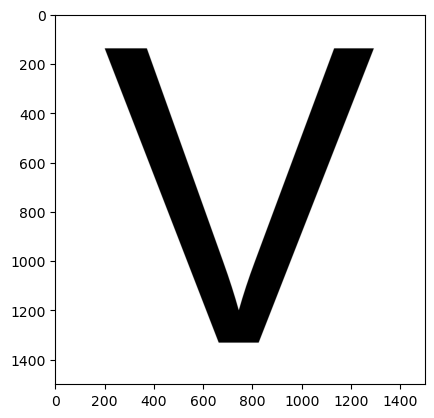

In [3]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
image = Image.open('data/V.png')
# image = image.filter(ImageFilter.GaussianBlur(radius=60))
plt.imshow(image)
image = image.rotate(-90)
image = np.array(image)
image = image.mean(axis=2)
image = image/image.max()

pts_x = np.linspace(0,1,image.shape[0])
pts_y = np.linspace(0,1,image.shape[1])

def coords_2_params_gt(xy):
    x, y = xy
    c = interp2d(x,y,pts_x,pts_y,image)
    return jnp.stack([0.5,0.10,0.20,0.1,0.0]) + c*jnp.stack([0.2,0.02,0.04,0.0,0.0])

In [4]:
# Functions to identify the boundary nodes
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-5)
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-5)
def top(point):
    return jnp.isclose(point[1], Ly, atol=1e-5)
def right(point):
    return jnp.isclose(point[0], Lx, atol=1e-5)
def bottom_left(point):
    return jnp.logical_and(jnp.logical_and(bottom(point), left(point)), jnp.isclose(point[2], 0., atol=1e-5))

lmb_hist = [1.05, 1.10, 1.15, 1.20]
n_elem = Nx*Ny

# Functions to assign dirichlet BCs
def zero_dirichlet(point):
    return 0.
def lmbx_max_dirichlet(point, lmbx_max):
    return Lx*lmbx_max - 1.0
def lmby_max_dirichlet(point, lmby_max):
    return Ly*lmby_max - 1.0
F_hist_goh = []
P_hist_goh = []

In [5]:
# Equibiaxial
for lmb_max in lmb_hist:    
    dirichlet_bc_info = [
        [bottom,            left,           top,                                        right,                                  ],
        [1,                 0,              1,                                          0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),   lambda p: lmbx_max_dirichlet(p, lmb_max)]
    ]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    # params = vmap(coords_2_params_gt)(elem_X)
    params = []
    for xy in elem_X:
        params.append(coords_2_params_gt(xy))
    params = np.expand_dims(params, 1)
    params_vec = jnp.repeat(params, axis=1, repeats=4)
    problem.set_params(params_vec)


    u = solver(problem, use_petsc=True)
    u_grad = np.mean(problem.sol_to_grad(u), axis=1)
    F = u_grad + np.eye(2)

    P = GOH_P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist_goh.append(F)
    P_hist_goh.append(P)

[07-16 11:06:02][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[07-16 11:06:02][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[07-16 11:06:02][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[07-16 11:06:02][DEBUG] jax_fem: Done pre-computations, took 0.6079580783843994 [s]
[07-16 11:06:02][INFO] jax_fem: Solving a problem with 2500 cells, 2601x2 = 5202 dofs.
[07-16 11:06:04][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[07-16 11:06:04][DEBUG] jax_fem: Start timing
[07-16 11:06:04][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[07-16 11:06:05][DEBUG] jax_fem: Function split_and_compute_cell took 0.7565 seconds
[07-16 11:06:05][DEBUG] jax_fem: Creating sparse matrix with scipy...
[07-16 11:06:06][DEBUG] jax_fem: Linear guess solve...
[07-16 11:06:06][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[07-16 11:06:06][DEBUG] jax_fem: PET

In [6]:
# Uniaxial in x
for lmb_max in lmb_hist:
    dirichlet_bc_info = [
        [bottom,            left,           right,                                  ],
        [1,                 0,              0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmbx_max_dirichlet(p, lmb_max)]
    ]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    problem.set_params(params_vec)


    node_x = solver(problem, use_petsc=True)
    u_grad = np.mean(problem.sol_to_grad(node_x), axis=1)
    F = u_grad + np.eye(2)
    P = GOH_P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist_goh.append(F)
    P_hist_goh.append(P)

[07-16 11:06:15][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[07-16 11:06:15][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[07-16 11:06:15][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[07-16 11:06:16][DEBUG] jax_fem: Done pre-computations, took 0.2571260929107666 [s]
[07-16 11:06:16][INFO] jax_fem: Solving a problem with 2500 cells, 2601x2 = 5202 dofs.
[07-16 11:06:16][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[07-16 11:06:16][DEBUG] jax_fem: Start timing
[07-16 11:06:16][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[07-16 11:06:16][DEBUG] jax_fem: Function split_and_compute_cell took 0.6138 seconds
[07-16 11:06:16][DEBUG] jax_fem: Creating sparse matrix with scipy...
[07-16 11:06:16][DEBUG] jax_fem: Linear guess solve...
[07-16 11:06:16][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[07-16 11:06:16][DEBUG] jax_fem: PET

In [7]:
# Uniaxial in y
for lmb_max in lmb_hist:
    dirichlet_bc_info = [
        [bottom,            left,           top,                                     ],
        [1,                 0,              1,                                       ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),]
    ]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    problem.set_params(params_vec)


    node_x = solver(problem, use_petsc=True)
    u_grad = np.mean(problem.sol_to_grad(node_x), axis=1)
    F = u_grad + np.eye(2)
    P = GOH_P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist_goh.append(F)
    P_hist_goh.append(P)

[07-16 11:06:19][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[07-16 11:06:19][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[07-16 11:06:19][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[07-16 11:06:20][DEBUG] jax_fem: Done pre-computations, took 0.2479548454284668 [s]
[07-16 11:06:20][INFO] jax_fem: Solving a problem with 2500 cells, 2601x2 = 5202 dofs.
[07-16 11:06:20][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[07-16 11:06:20][DEBUG] jax_fem: Start timing
[07-16 11:06:20][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[07-16 11:06:20][DEBUG] jax_fem: Function split_and_compute_cell took 0.5419 seconds
[07-16 11:06:20][DEBUG] jax_fem: Creating sparse matrix with scipy...
[07-16 11:06:20][DEBUG] jax_fem: Linear guess solve...
[07-16 11:06:20][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[07-16 11:06:20][DEBUG] jax_fem: PET

In [8]:
F_hist_goh = np.array(F_hist_goh)
P_hist_goh = np.array(P_hist_goh)

F_mean = F_hist_goh[-1].mean(axis=0)
params_gt = params_vec[:,0,:]

0.5055526831763707 0.707773756446919


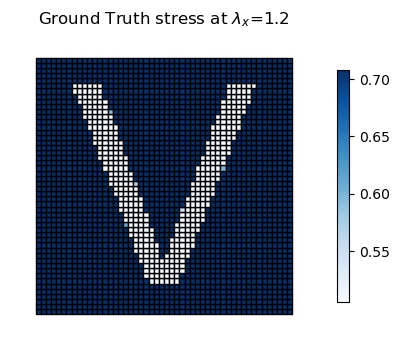

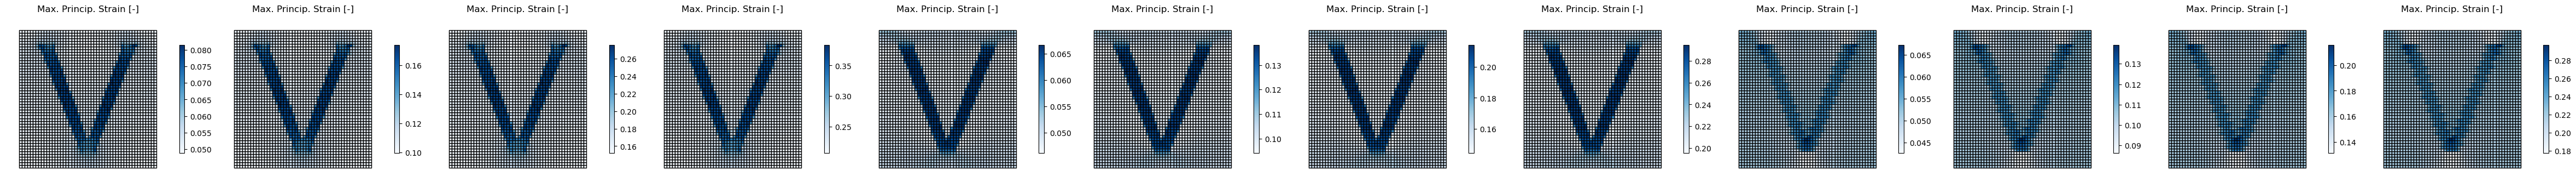

In [9]:
GOH_P_vmap2 = vmap(GOH_P, in_axes=(None,0,None))
fig, ax = plt.subplots(figsize=(5,4))
ugrad = F_mean - np.eye(2)
P_gt = GOH_P_vmap2(ugrad, params_gt,2)[:,1,1]
plotmesh(mesh.cells, mesh.points, P_gt, title='Ground Truth stress at $\lambda_x$=1.2', ax=ax); 
print(P_gt.min(), P_gt.max())



fig, axes = plt.subplots(1,12,figsize=(60,4))
t_hist = np.arange(len(lmb_hist)*3)
for t, F, P, ax in zip(t_hist, F_hist_goh, P_hist_goh, axes):
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)

    plotmesh(mesh.cells, mesh.points, mps, title='Max. Princip. Strain [-]', ax=ax); 

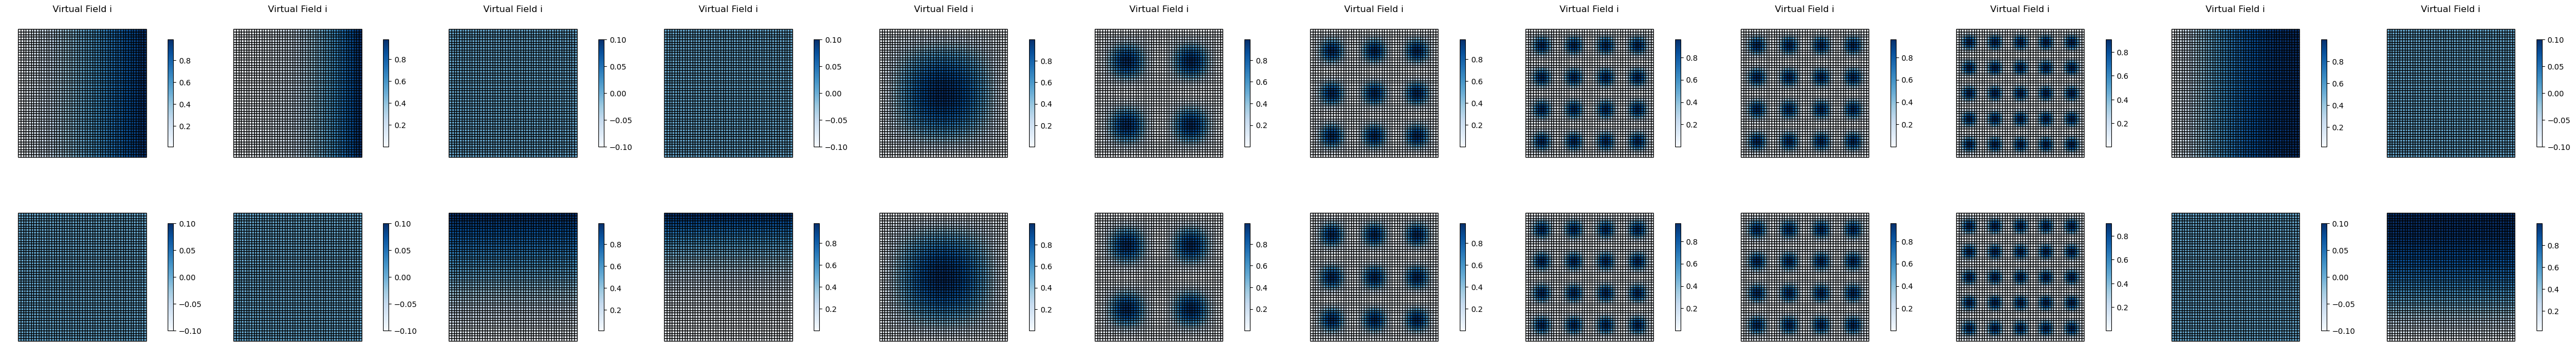

In [10]:
h = 1.0
w = 1.0
VF_list = [VF1, VF1, VF2, VF2, VF3, VF4, VF4, VF4, VF4, VF4, VF5, VF6]
p_list =  [1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 3.0, 4.0, 4.0, 5.0, 1.0, 1.0]

x_elem, y_elem = elem_X.T
x_node, y_node = mesh.points.T
U, gradU = [], []
fig, axes = plt.subplots(2,len(VF_list),figsize=(len(VF_list)*5,8))
for ax, VF, p in zip(axes.T, VF_list, p_list):
    Ui, gradUi = VF_and_grad_2(VF, x_elem, y_elem, x_node, y_node, h, w, p)
    plotmesh(mesh.cells, mesh.points, Ui[mesh.cells,0].mean(axis=1), title='Virtual Field i', ax=ax[0]); 
    plotmesh(mesh.cells, mesh.points, Ui[mesh.cells,1].mean(axis=1), title=None, ax=ax[1]); 
    U.append(Ui)
    gradU.append(gradUi)
U, gradU = np.array(U), np.array(gradU)

In [11]:
dL = Lx/Nx
dA = dL*dL
# identify the boundaries
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the reaction forces by integrating the stresses of the boundary elements
rgt_bd_frc = np.sum(P_hist_goh[:,rgt_bd_elems,0,0]*dL, axis=1)
lft_bd_frc = np.sum(P_hist_goh[:,lft_bd_elems,0,0]*dL, axis=1)
top_bd_frc = np.sum(P_hist_goh[:,top_bd_elems,1,1]*dL, axis=1)
bot_bd_frc = np.sum(P_hist_goh[:,bot_bd_elems,1,1]*dL, axis=1)
Fx = jnp.array(0.5*(rgt_bd_frc + lft_bd_frc))
Fy = jnp.array(0.5*(top_bd_frc + bot_bd_frc))

rgt_bd_nodes = np.where(np.isclose(mesh.points[:,0], 1.0))[0]
top_bd_nodes = np.where(np.isclose(mesh.points[:,1], 1.0))[0]
lft_bd_nodes = np.where(np.isclose(mesh.points[:,0], 0.0))[0]
bot_bd_nodes = np.where(np.isclose(mesh.points[:,1], 0.0))[0]

In [12]:
def eval_W_int(P, gradU):
    return jnp.einsum('ijk,ijk', P, gradU)*dA
def eval_W_ext(U, Fx, Fy):
    W_rgt = jnp.sum(U[rgt_bd_nodes, 0]*Fx*dL)
    W_top = jnp.sum(U[top_bd_nodes, 1]*Fy*dL)
    W_lft = jnp.sum(U[lft_bd_nodes, 0]*Fx*dL)
    W_bot = jnp.sum(U[bot_bd_nodes, 1]*Fy*dL)
    return W_rgt + W_top# + W_lft + W_bot

def get_vworks(params):
    W_int_vec = []
    W_ext_vec = []
    for step in range(len(F_hist_goh)):
        F = F_hist_goh[step]
        u_grad = jnp.array(F - np.eye(2))
        P = GOH_P_vmap(u_grad, params, 2)
        W_int = []
        W_ext = []
        for i_vf in range(len(U)):
            W_int.append(eval_W_int(P, gradU[i_vf]))
            W_ext.append(eval_W_ext(U[i_vf], Fx[step], Fy[step]))
        W_int_vec.append(jnp.array(W_int))
        W_ext_vec.append(jnp.array(W_ext))
    W_int_vec = jnp.array(W_int_vec) # [n_steps, n_virtualfields]
    W_ext_vec = jnp.array(W_ext_vec)
    return W_int_vec, W_ext_vec

@jit
def obj_fn(params):
    params = unravel(jnp.exp(params))
    W_int_vec, W_ext_vec = get_vworks(params)
    return jnp.sum((W_int_vec-W_ext_vec)**2)
g = grad(obj_fn)

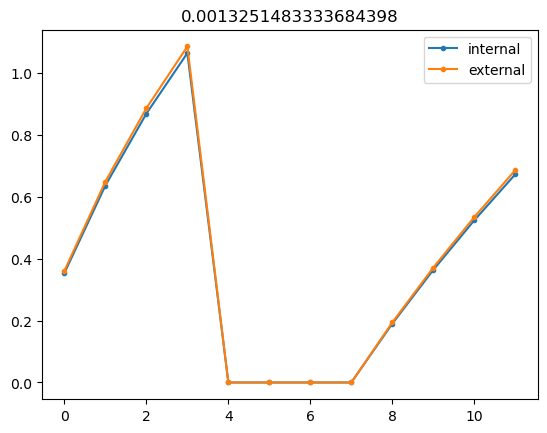

In [16]:
i_vf = 3
W_int_vec, W_ext_vec = get_vworks(params_gt)
W_int = W_int_vec[:,i_vf]
W_ext = W_ext_vec[:,i_vf]
plt.plot(W_int, '.-', label='internal')
plt.plot(W_ext, '.-', label='external')
plt.legend()
plt.title(str(np.sum((W_int - W_ext)**2))); 

Iteration: 00100, Objective: 7.10e-03
Iteration: 00200, Objective: 3.43e-03
Iteration: 00300, Objective: 1.94e-03
Iteration: 00400, Objective: 1.37e-03
Iteration: 00500, Objective: 9.80e-04
Iteration: 00600, Objective: 7.52e-04
Iteration: 00700, Objective: 6.88e-04
Iteration: 00800, Objective: 6.09e-04
Iteration: 00900, Objective: 5.16e-04
Iteration: 01000, Objective: 4.19e-04
Iteration: 01100, Objective: 3.89e-04
Iteration: 01200, Objective: 3.49e-04
Iteration: 01300, Objective: 3.34e-04
Iteration: 01400, Objective: 3.16e-04
Iteration: 01500, Objective: 2.75e-04
Iteration: 01600, Objective: 2.67e-04
Iteration: 01700, Objective: 2.42e-04
Iteration: 01800, Objective: 2.30e-04
Iteration: 01900, Objective: 1.94e-04
Iteration: 02000, Objective: 1.85e-04
Iteration: 02100, Objective: 1.81e-04
Iteration: 02200, Objective: 1.73e-04
Iteration: 02300, Objective: 1.60e-04
Iteration: 02400, Objective: 1.57e-04
Iteration: 02500, Objective: 1.52e-04
Iteration: 02600, Objective: 1.49e-04
Iteration: 0

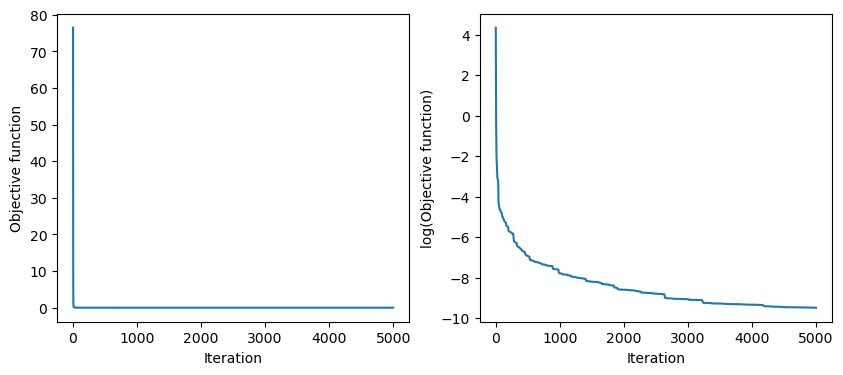

In [14]:
class OptimizationCallback:
    def __init__(self):
        self.iteration = 0
        self.history = {'iter':[], 'fval':[]}

    def __call__(self, xk):
        self.iteration += 1
        fval = obj_fn(xk)
        self.history['iter'].append(self.iteration)
        self.history['fval'].append(fval)
        print_freq = 100
        if self.iteration % print_freq == 0:
            print(f"Iteration: {self.iteration:05d}, Objective: {fval:.2e}")

params_vfm = np.array(params_gt[0])[None,:]
params_vfm[0,-1] = 1.0
params_vfm = np.repeat(params_vfm, len(elem_X), axis=0)
params_vfm, unravel = ravel_pytree(params_vfm)


callback = OptimizationCallback()
sol = minimize(obj_fn, jac = g, x0=params_vfm, options={'maxiter':5000, 'gtol':1e-12}, callback=callback, method='CG')

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(callback.history['iter'], callback.history['fval'])
ax[0].set(xlabel='Iteration', ylabel='Objective function')
ax[1].plot(callback.history['iter'], np.log(callback.history['fval']))
ax[1].set(xlabel='Iteration', ylabel='log(Objective function)'); 

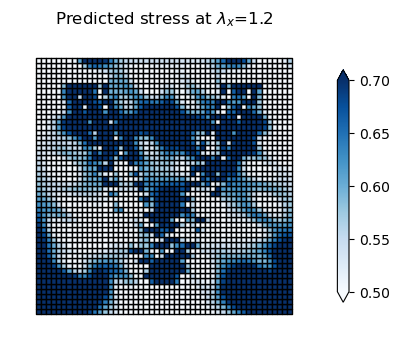

In [28]:
params_vfm = unravel(jnp.exp(sol.x))
fig, ax = plt.subplots(figsize=(5,4))
ugrad = F_mean - np.eye(2)
P_vfm = GOH_P_vmap2(ugrad, params_vfm, 2)[:,1,1]
plotmesh(mesh.cells, mesh.points, P_vfm, title='Predicted stress at $\lambda_x$=1.2', ax=ax, extent=[0.5,0.7], extend='both'); 

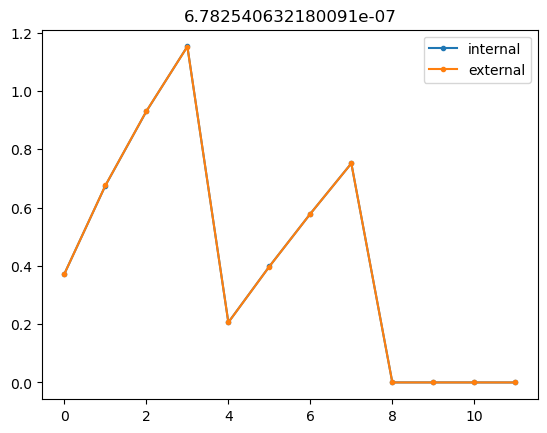

In [29]:
i_vf = 0
W_int_vec, W_ext_vec = get_vworks(params_vfm)
W_int = W_int_vec[:,i_vf]
W_ext = W_ext_vec[:,i_vf]
plt.plot(W_int, '.-', label='internal')
plt.plot(W_ext, '.-', label='external')
plt.legend()
plt.title(str(np.sum((W_int - W_ext)**2))); 